# Comparing the Correlation results of SEACells and ct + time

In [1]:
#read in the results from correlation analysis, then aggregate
import pandas as pd

cor_res_100kb_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")
print(cor_res_100kb_ctt.head())
cor_100kb_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
print(cor_100kb_df_sc.head())


  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj  
0  0.034600       1.460927  
1  0.173677       0.760259  
2  0.472269       0.325810  
3  0.217494       0.662553  
4  0.748452       0.125836  
  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.121149  0.000016         4.791006   
1  100kb  a1cf  12-6190483-6191143     0.117048  0.000031         4.506702   
2  100kb  a1cf  12-6225169-6226018     0.061143  0.029989         1.523041   
3  100kb  a1cf  12-6114452-6114950     0.0603

In [2]:
# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb_ctt["category"] = cor_res_100kb_ctt.apply(classify_pair, axis=1)

#aggregate the number of significant peaks per gene and category  
agg_cor_100kb_ctt_df = (
    cor_res_100kb_ctt
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
print(agg_cor_100kb_ctt_df.head())


cor_100kb_df_sc["category"] = cor_100kb_df_sc.apply(classify_pair, axis=1)
agg_cor_100kb_sc = (
    cor_100kb_df_sc
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
print(agg_cor_100kb_sc.head())

  window  gene         category  count
0  100kb  a1cf  non-significant     67
1  100kb  a1cf    sig. positive     28
2  100kb  a2ml  non-significant     70
3  100kb  a2ml    sig. positive      7
4  100kb  aaas  non-significant     93
  window  gene         category  count
0  100kb  a1cf  non-significant     38
1  100kb  a1cf    sig. positive     57
2  100kb  a2ml  non-significant     35
3  100kb  a2ml    sig. positive     42
4  100kb  aaas  non-significant     19


In [3]:
#merge the two aggregated dataframes on window, gene, and category
merged_agg_df = pd.merge(
    agg_cor_100kb_ctt_df,
    agg_cor_100kb_sc,
    on=["window", "gene", "category"],
    how="outer",
    suffixes=("_ctt", "_sc")
)
print(merged_agg_df.head())

  window  gene         category  count_ctt  count_sc
0  100kb  a1cf  non-significant       67.0      38.0
1  100kb  a1cf    sig. positive       28.0      57.0
2  100kb  a2ml  non-significant       70.0      35.0
3  100kb  a2ml    sig. positive        7.0      42.0
4  100kb  aaas  non-significant       93.0      19.0


/tmp/ipykernel_1407594/701105123.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_sig_df["n_genes"] = plot_sig_df.groupby(


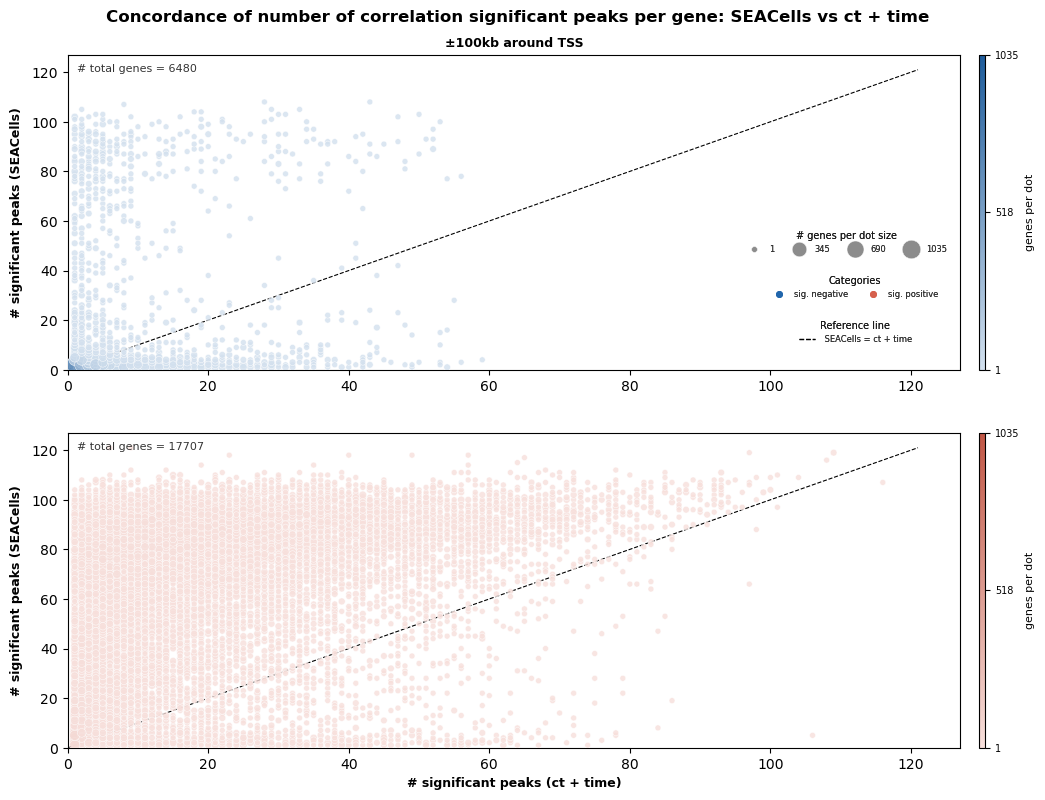

In [4]:
#plot the number of significant peaks per gene in correlation results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = merged_agg_df.dropna(subset=["count_ctt", "count_sc", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

# Count genes per (count_ctt, count_sc, window, category) position
plot_sig_df["n_genes"] = plot_sig_df.groupby(
    ["window", "category", "count_ctt", "count_sc"] 
)["gene"].transform("count") #count the number of genes per unique (x, y, window, category) position

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_ctt", "count_sc", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(12, 9),
    sharex=False, sharey=True,
)

axis_max = plot_sig_df[["count_ctt", "count_sc"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_ctt"], data["count_sc"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, axis_max*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# significant peaks (SEACells)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (ct + time)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        ax.set_xticks(np.arange(0, plot_sig_df[["count_ctt", "count_sc"]].max().max()+ 1, 20))
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="lower right",
    bbox_to_anchor=(0.864, 0.65),
    ncol= 4,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.857, 0.6),
    ncol=2,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" SEACells = ct + time")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.835, 0.55),
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)


plt.yticks(np.arange(0, plot_sig_df[["count_ctt", "count_sc"]].max().max()+ 1, 20))

plt.suptitle(
    "Concordance of number of correlation significant peaks per gene: SEACells vs ct + time",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()



/tmp/ipykernel_1407594/4232060371.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(


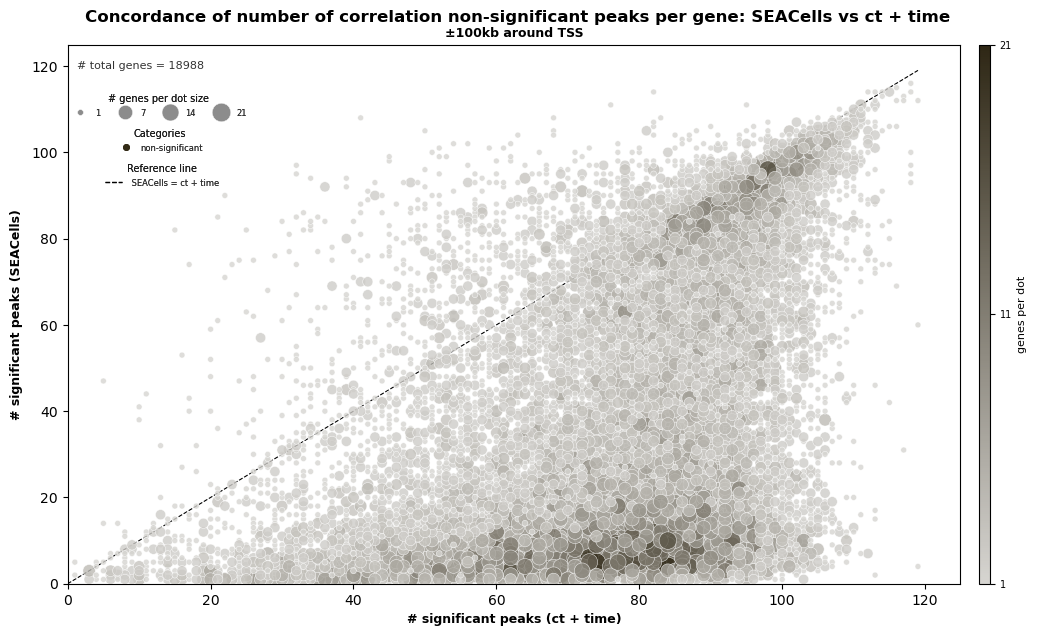

In [5]:
#plot the number of significant peaks per gene in correlation results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = merged_agg_df.dropna(subset=["count_ctt", "count_sc", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_non_sig_df = plot_df[plot_df["category"] == "non-significant"].copy()

# Count genes per (count_ctt, count_sc, window, category) position
plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(
    ["window", "category", "count_ctt", "count_sc"] 
)["gene"].transform("count")

category_base_colors = {
    "non-significant": "#332b17",
}
category_order = ["non-significant"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_non_sig_df.drop_duplicates(
    subset=["count_ctt", "count_sc", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(12, 7),
    sharex=False, sharey=True,
)

axis_max = plot_non_sig_df[["count_ctt", "count_sc"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes,   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_ctt"], data["count_sc"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, axis_max*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# significant peaks (SEACells)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (ct + time)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        #ax.set_xticks(np.arange(0, plot_non_sig_df[["count_ctt", "count_sc"]].max().max()+ 1, 2))
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="upper left",
    bbox_to_anchor=(0.122, 0.82),
    ncol= 4,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="upper left",
    bbox_to_anchor=(0.16, 0.77),
    ncol=2,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" SEACells = ct + time")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="upper left",
    bbox_to_anchor=(0.15, 0.72),
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)


# plt.yticks(np.arange(0, plot_non_sig_df[["count_ctt", "count_sc"]].max().max()+ 1, 2))

plt.suptitle(
    "Concordance of number of correlation non-significant peaks per gene: SEACells vs ct + time",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()



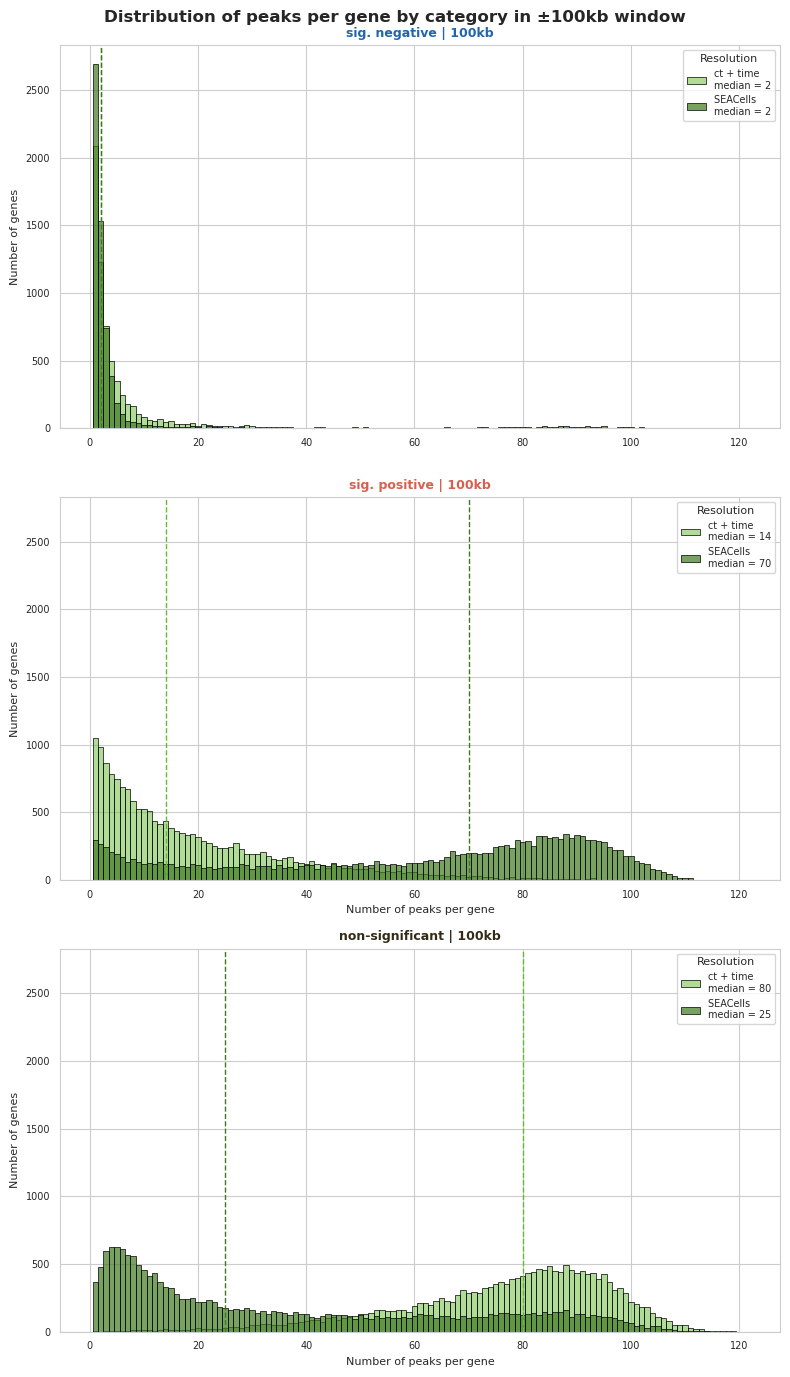

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = merged_agg_df.dropna(subset=["count_ctt", "count_sc", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df.copy()
plot_sig_df["category"] = pd.Categorical(
    plot_sig_df["category"],
    categories=["sig. negative", "sig. positive", "non-significant"],
    ordered=True,
)

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["gene", "window", "category"]
).copy()
category_order = ["sig. negative", "sig. positive", "non-significant"]
category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
    "non-significant": "#332b17",
}
window_labels = ["100kb"]
method_colors = {"ct + time": "#63bb31", "sc": "#407920"}

fig, axes = plt.subplots(len(category_order),1, figsize=(8, 14), sharex=True, sharey=True)

for row_idx, win in enumerate(window_labels):
    win_data = plot_dedup[plot_dedup["window"] == win]

    for col_idx, cat in enumerate(category_order):
        ax = axes[col_idx]
        cat_data = win_data[win_data["category"] == cat]

        combined_counts = pd.concat([win_data["count_ctt"], win_data["count_sc"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue
        
        #median values for each method
        median_ctt = cat_data["count_ctt"].median()
        median_sc = cat_data["count_sc"].median()

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot ct + time histogram
        sns.histplot(
            cat_data["count_ctt"],
            #bins=bin_edges,
            alpha=0.5,
            label=f"ct + time \nmedian = {median_ctt:.0f}",
            color=method_colors["ct + time"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot SEACElls histogram
        sns.histplot(
            cat_data["count_sc"],
            #bins=bin_edges,
            alpha=0.7,
            label=f"SEACells \nmedian = {median_sc:.0f}",
            color=method_colors["sc"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Number of genes", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold", color=category_base_colors.get(cat, "k"))
        ax.tick_params(labelsize=7)
        ax.legend(loc = "upper right", fontsize=7, title="Resolution", title_fontsize=8, frameon=True)

        #add median lines for each histogram
        median_ctt = cat_data["count_ctt"].median()
        median_sc = cat_data["count_sc"].median()
        ax.axvline(median_ctt, color=method_colors["ct + time"], linestyle="--", linewidth=1)
        ax.axvline(median_sc, color=method_colors["sc"], linestyle="--", linewidth=1)
                
        for ax in axes:
            ax.tick_params(axis='x', labelbottom=True)
       

fig.suptitle("Distribution of peaks per gene by category in ±100kb window", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

In [21]:
#load the window_assignment_with_peak_counts_100kb.csv file to check if the new columns are there
import pandas as pd
window_assignment = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/window_assignment_with_peak_counts_100kb.csv")
print(window_assignment.head())

#load the OLS results for ct + time and SEACells to add the annotations
cor_res_100kb_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")
print(cor_res_100kb_ctt.head())

cor_100kb_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
cor_100kb_df_sc.head()

  gene_id                                     assigned_peaks  \
0    a1cf  ["['12-6186644-6187111'", " '12-6190483-619114...   
1    a2ml  ["['15-21143884-21144162'", " '15-21033797-210...   
2    aaas  ["['9-323370-323691'", " '9-209853-211311'", "...   
3    aacs  ["['5-18949828-18950713'", " '5-18811696-18812...   
4   aadac  ["['15-1052335-1053001'", " '15-1029184-103007...   

   num_assigned_peaks peak_count_window  
0                  95            90-100  
1                  77             70-80  
2                 110           100-110  
3                  88             80-90  
4                 100            90-100  
  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj
0,100kb,a1cf,12-6186644-6187111,0.121149,0.000016,4.791006,0.000055,4.261565
1,100kb,a1cf,12-6190483-6191143,0.117048,0.000031,4.506702,0.000099,4.004141
2,100kb,a1cf,12-6225169-6226018,0.061143,0.029989,1.523041,0.048167,1.317250
3,100kb,a1cf,12-6114452-6114950,0.060388,0.032080,1.493760,0.051156,1.291101
4,100kb,a1cf,12-6140521-6140735,0.012429,0.659394,0.180855,0.714356,0.146085


In [22]:
#rename the window labels in the long format dataframes to be more descriptive
window_label_mapping = {
    '0-10': '0 < 10',
    '10-20': '10 < 20',
    '20-30': '20 < 30',
    '30-40': '30 < 40',
    '40-50': '40 < 50',
    '50-60': '50 < 60',
    '60-70': '60 < 70',
    '70-80': '70 < 80',
    '80-90': '80 < 90',
    '90-100': '90 < 100',
    '100-110': '100 < 110',
    '110-120': '110 < 120',
    '120-130': '120 < 130',
}

window_assignment["peak_count_window"] = window_assignment["peak_count_window"].replace(window_label_mapping)
window_assignment.head()

,gene_id,assigned_peaks,num_assigned_peaks,peak_count_window
0,a1cf,"[""['12-6186644-6187111'"", "" '12-6190483-619114...",95,90 < 100
1,a2ml,"[""['15-21143884-21144162'"", "" '15-21033797-210...",77,70 < 80
2,aaas,"[""['9-323370-323691'"", "" '9-209853-211311'"", ""...",110,100 < 110
3,aacs,"[""['5-18949828-18950713'"", "" '5-18811696-18812...",88,80 < 90
4,aadac,"[""['15-1052335-1053001'"", "" '15-1029184-103007...",100,90 < 100


In [23]:
#rename gene_id column to gene in the window_assignment dataframe to match the cor_res_100kb_ctt and cor_100kb_df_sc dataframes
window_assignment = window_assignment.rename(columns={"gene_id": "gene"})

#add window_assignment columns to the cor_res_100kb_ctt and cor_res_100kb_sc dataframes
cor_res_100kb_ctt = pd.merge(
    cor_res_100kb_ctt,
    window_assignment[["gene", "peak_count_window"]],
    on="gene",
    how="left"
)
cor_res_100kb_sc = pd.merge(
    cor_100kb_df_sc,
    window_assignment[["gene", "peak_count_window"]],
    on="gene",
    how="left"
)

print(cor_res_100kb_ctt.head())
print(cor_res_100kb_sc.head())

  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj peak_count_window  
0  0.034600       1.460927          90 < 100  
1  0.173677       0.760259          90 < 100  
2  0.472269       0.325810          90 < 100  
3  0.217494       0.662553          90 < 100  
4  0.748452       0.125836          90 < 100  
  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.121149  0.000016         4.791006   
1  100kb  a1cf  12-6190483-6191143     0.117048  0.000031         4.506702   
2  100kb  a1cf 

In [24]:
# classify every peak–gene pair into one of three categories to cor results

def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb_sc["category"] = cor_res_100kb_sc.apply(classify_pair, axis=1)
cor_res_100kb_ctt["category"] = cor_res_100kb_ctt.apply(classify_pair, axis=1)

In [25]:
#create a dictionary with the significant peaks for each gene for each peak_count_window, by filtering the results for significant peaks and grouping by gene and peak_count_window, and saving the significant peaks in a list for each gene and peak_count_window
window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

sig_cor_df_ctt = cor_res_100kb_ctt[cor_res_100kb_ctt["category"].isin(["sig. negative", "sig. positive"])] 

sig_peaks_by_gene_cor_ctt = {} 

for window in window_labels:
    sig_peaks_by_gene_cor_ctt[window] = {}
    window_df = sig_cor_df_ctt[sig_cor_df_ctt["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_cor_ctt[window][gene_id] = group["peak"].tolist()

print(next(iter(sig_peaks_by_gene_cor_ctt.items())))

sig_cor_df_sc = cor_res_100kb_sc[cor_res_100kb_sc["category"].isin(["sig. negative", "sig. positive"])]
sig_peaks_by_gene_cor_sc = {}

for window in window_labels:
    sig_peaks_by_gene_cor_sc[window] = {}
    window_df = sig_cor_df_sc[sig_cor_df_sc["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_cor_sc[window][gene_id] = group["peak"].tolist()

print(next(iter(sig_peaks_by_gene_cor_sc.items())))


('0 < 10', {'si:ch211-141e20.2': ['9-19696386-19696788', '9-19813955-19814167'], 'si:ch211-207e19.2': ['4-56090517-56091419'], 'si:ch211-237a4.2': ['4-56495735-56496139'], 'si:dkey-193i10.4': ['4-71177637-71177844'], 'si:dkey-57k17.1': ['4-58076020-58076594', '4-58066540-58067258', '4-58079155-58079357'], 'si:dkey-71l4.4': ['4-75511479-75511776'], 'si:dkeyp-80d11.4': ['4-70942817-70943062'], 'zgc:174275': ['4-56326906-56327745', '4-56323357-56324154'], 'zgc:174650': ['4-40981021-40981255'], 'znf1072': ['4-42999864-43000249', '4-43142059-43142361'], 'znf973': ['4-37320494-37320726']})
('0 < 10', {'si:ch211-141e20.2': ['9-19730435-19731105', '9-19810800-19811101', '9-19813192-19813597', '9-19696386-19696788', '9-19685229-19685437', '9-19813955-19814167', '9-19809275-19809818', '9-19798180-19798460', '9-19818336-19818574'], 'si:ch211-207e19.2': ['4-56090517-56091419', '4-56110786-56111229'], 'si:ch211-227p7.1': ['4-56638846-56640646'], 'si:ch211-237a4.2': ['4-56495735-56496139'], 'si:ch21

In [26]:
#define functions to calculate jaccard similarity and retention between two sets of peaks

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union > 0 else 0

def retention(set_small, set_large):
    a, b = set(set_small), set(set_large)
    return len(a & b) / len(a) if len(a) > 0 else 0

In [14]:
#number of genes in both datasets
genes_in_ctt = set(cor_res_100kb_ctt["gene"].unique())
genes_in_sc = set(cor_res_100kb_sc["gene"].unique())
common_genes = genes_in_ctt.intersection(genes_in_sc)
print(f"Number of genes in ct + time: {len(genes_in_ctt)}")
print(f"Number of genes in SEACells: {len(genes_in_sc)}")
print(f"Number of common genes: {len(common_genes)}")

Number of genes in ct + time: 19166
Number of genes in SEACells: 19169
Number of common genes: 19166


In [27]:
#number of gens with significant peaks in both datasets
sig_genes_in_ctt = set(sig_cor_df_ctt["gene"].unique())
sig_genes_in_sc = set(sig_cor_df_sc["gene"].unique())
common_sig_genes = sig_genes_in_ctt.intersection(sig_genes_in_sc)
print(f"Number of genes with significant peaks in ct + time: {len(sig_genes_in_ctt)}")
print(f"Number of genes with significant peaks in SEACells: {len(sig_genes_in_sc)}")
print(f"Number of common genes with significant peaks: {len(common_sig_genes)}")

Number of genes with significant peaks in ct + time: 18424
Number of genes with significant peaks in SEACells: 19094
Number of common genes with significant peaks: 18397


In [28]:
#compute the jaccard similarity and retention for each gene and each pair of windows, and store the results in a long format dataframe and a matrix format dataframe for both jaccard and retention

all_genes = set(sig_cor_df_sc["gene"].unique()) #take the union of the genes from both dataframes to make sure we include all genes that have significant peaks in either dataset

window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

def build_long_and_matrix(score_fn, dict1, dict2, window_labels, all_genes, value_name):
    records = []
    for w1 in window_labels:
        for w2 in window_labels:
            for gene in all_genes:
                peaks1 = dict1[w1].get(gene, [])
                peaks2 = dict2[w2].get(gene, [])
                if len(peaks1) > 0 and len(peaks2) > 0:
                    records.append({
                        "w1": w1,
                        "w2": w2,
                        "gene": gene,
                        value_name: score_fn(peaks1, peaks2)
                    })

    long_df = pd.DataFrame(records)
    matrix = long_df.pivot_table(
        index="w1", columns="w2", values=value_name, aggfunc="mean"
    ).reindex(index=window_labels, columns=window_labels)

    return long_df, matrix


# --- Jaccard ---
jaccard_long, jaccard_matrix = build_long_and_matrix(
    jaccard, sig_peaks_by_gene_cor_ctt, sig_peaks_by_gene_cor_sc,
    window_labels, all_genes, value_name="jaccard"
)

# --- Retention (ctt -> sc) ---
retention_long_ctt_sc, retention_matrix_ctt_sc = build_long_and_matrix(
    retention, sig_peaks_by_gene_cor_ctt, sig_peaks_by_gene_cor_sc,
    window_labels, all_genes, value_name="retention"
)

# --- Retention (sc -> ctt) ---
retention_long_sc_ctt, retention_matrix_sc_ctt = build_long_and_matrix(
    retention, sig_peaks_by_gene_cor_sc, sig_peaks_by_gene_cor_ctt,
    window_labels, all_genes, value_name="retention"
)

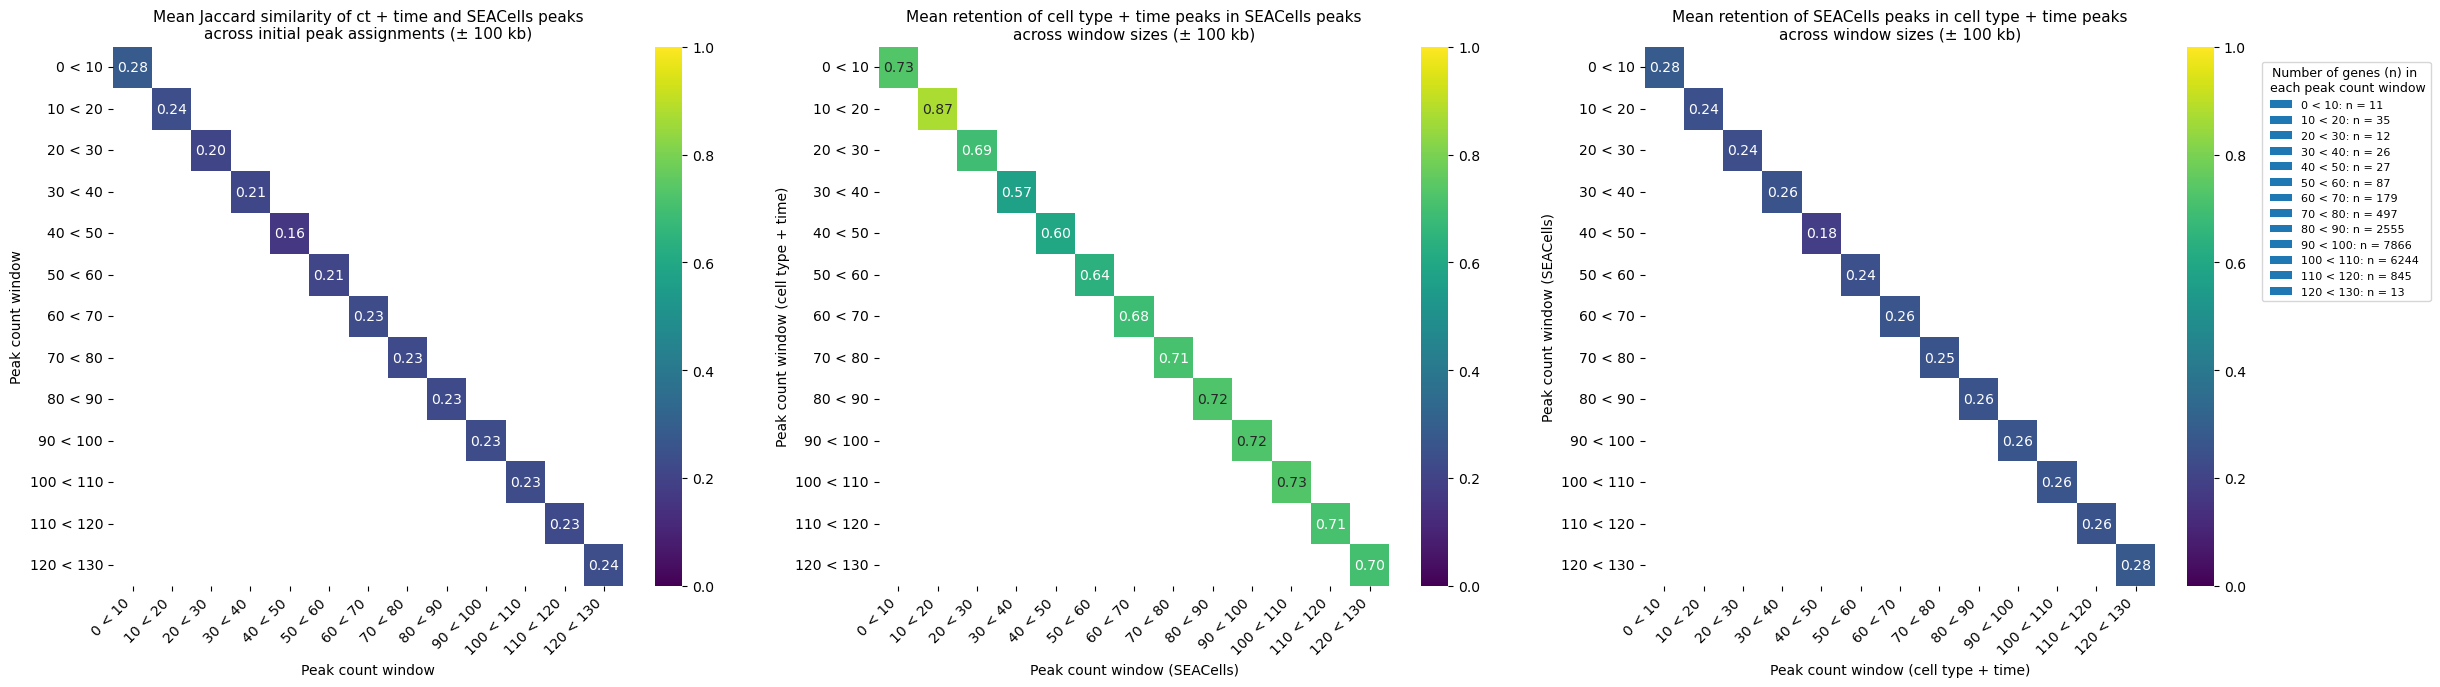

<Figure size 640x480 with 0 Axes>

In [29]:
#defining a function to create annotation strings for the heatmap, including the mean value and the number of genes that contributed to that mean value for each cell in the matrix
def make_annot(matrix, counts):
    annot = matrix.copy().astype(object)
    for w1 in matrix.index:
        for w2 in matrix.columns:
            val = matrix.loc[w1, w2]
            n = counts.loc[w1, w2]
            if pd.isna(val):
                annot.loc[w1, w2] = ""
            else:
                n_int = int(n) if not pd.isna(n) else 0
                annot.loc[w1, w2] = f"{val:.2f}\n(n={n_int})"
    return annot

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import seaborn as sns

window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

# --- counts for each comparison ---
jaccard_counts = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_ctt_sc = retention_long_ctt_sc.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_sc_ctt = retention_long_sc_ctt.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)


# --- annotation strings ---
jaccard_annot = make_annot(jaccard_matrix, jaccard_counts)
retention_annot_ctt_sc = make_annot(retention_matrix_ctt_sc, retention_counts_ctt_sc)
retention_annot_sc_ctt = make_annot(retention_matrix_sc_ctt, retention_counts_sc_ctt)

vmin = 0
vmax = 1.0

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(28, 7))
#make annotation size smaller
sns.heatmap(jaccard_matrix.astype(float), annot= True, fmt=".2f", cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[0]) #make annotation size smaller
axes[0].set_xticklabels( jaccard_matrix.columns, rotation=45, ha="right")
axes[0].set_xlabel("Peak count window")
axes[0].set_ylabel("Peak count window")
axes[0].set_title("Mean Jaccard similarity of ct + time and SEACells peaks\nacross initial peak assignments (± 100 kb)", fontsize=11)

sns.heatmap(retention_matrix_ctt_sc.astype(float), annot= True, fmt=".2f", cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_xticklabels( retention_matrix_ctt_sc.columns, rotation=45, ha="right")
axes[1].set_xlabel("Peak count window (SEACells)")
axes[1].set_ylabel("Peak count window (cell type + time)")
axes[1].set_title("Mean retention of cell type + time peaks in SEACells peaks\nacross window sizes (± 100 kb)", fontsize=11 )

sns.heatmap(retention_matrix_sc_ctt.astype(float), annot= True, fmt=".2f", cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[2])
axes[2].set_xticklabels( retention_matrix_sc_ctt.columns, rotation=45, ha="right")
axes[2].set_xlabel("Peak count window (cell type + time)")
axes[2].set_ylabel("Peak count window (SEACells)")
axes[2].set_title("Mean retention of SEACells peaks in cell type + time peaks\nacross window sizes (± 100 kb)", fontsize=11)


# Create a custom legend with title number of genes contributing to each cell's mean value, e.g. 0<10: 6 genes, 10<20: 15 genes, etc.
legend_elements = []
for w in window_labels:
    n = jaccard_counts.loc[w, w]  # take the diagonal count as representative for that window size
    legend_elements.append(mpatches.Patch(label=f"{w}: n = { int(n)} "))
legend = plt.legend(handles=legend_elements, title="Number of genes (n) in \n each peak count window", loc="center right", bbox_to_anchor=(1.55, 0.75), fontsize=8, title_fontsize=9)
legend.get_title().set_ha("center")
plt.show()  # make room for the legend
plt.tight_layout()

In [30]:
#save the results of long format dataframes 
jaccard_long.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/jaccard_long_100kb_cor.csv", index=False)
retention_long_ctt_sc.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_ctt_sc_100kb_cor.csv", index=False)
retention_long_sc_ctt.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_sc_ctt_100kb_cor.csv", index=False)


In [32]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/jaccard_long_100kb_cor.csv")
retention_long_ctt_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_ctt_sc_100kb_cor.csv")
retention_long_sc_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_sc_ctt_100kb_cor.csv")

#print the first few rows of each dataframe to check if they are loaded correctly
print(jaccard_long.head())
print(retention_long_ctt_sc.head())
print(retention_long_sc_ctt.head())

       w1      w2               gene  jaccard
0  0 < 10  0 < 10   si:dkeyp-80d11.4      0.0
1  0 < 10  0 < 10   si:ch211-237a4.2      1.0
2  0 < 10  0 < 10             znf973      0.2
3  0 < 10  0 < 10  si:ch211-207e19.2      0.5
4  0 < 10  0 < 10            znf1072      0.4
       w1      w2               gene  retention
0  0 < 10  0 < 10   si:dkeyp-80d11.4        0.0
1  0 < 10  0 < 10   si:ch211-237a4.2        1.0
2  0 < 10  0 < 10             znf973        1.0
3  0 < 10  0 < 10  si:ch211-207e19.2        1.0
4  0 < 10  0 < 10            znf1072        1.0
       w1      w2               gene  retention
0  0 < 10  0 < 10   si:dkeyp-80d11.4        0.0
1  0 < 10  0 < 10   si:ch211-237a4.2        1.0
2  0 < 10  0 < 10             znf973        0.2
3  0 < 10  0 < 10  si:ch211-207e19.2        0.5
4  0 < 10  0 < 10            znf1072        0.4


In [33]:
#combine retention dataframes into one long format dataframe for easier plotting
retention_long_ctt_sc["comparison"] = "ct + time -> SEACells"
retention_long_sc_ctt["comparison"] = "SEACells -> ct + time"
retention_long_combined = pd.concat([retention_long_ctt_sc, retention_long_sc_ctt], ignore_index=True)
retention_long_combined.head()

,w1,w2,gene,retention,comparison
0,0 < 10,0 < 10,si:dkeyp-80d11.4,0.0,ct + time -> SEACells
1,0 < 10,0 < 10,si:ch211-237a4.2,1.0,ct + time -> SEACells
2,0 < 10,0 < 10,znf973,1.0,ct + time -> SEACells
3,0 < 10,0 < 10,si:ch211-207e19.2,1.0,ct + time -> SEACells
4,0 < 10,0 < 10,znf1072,1.0,ct + time -> SEACells


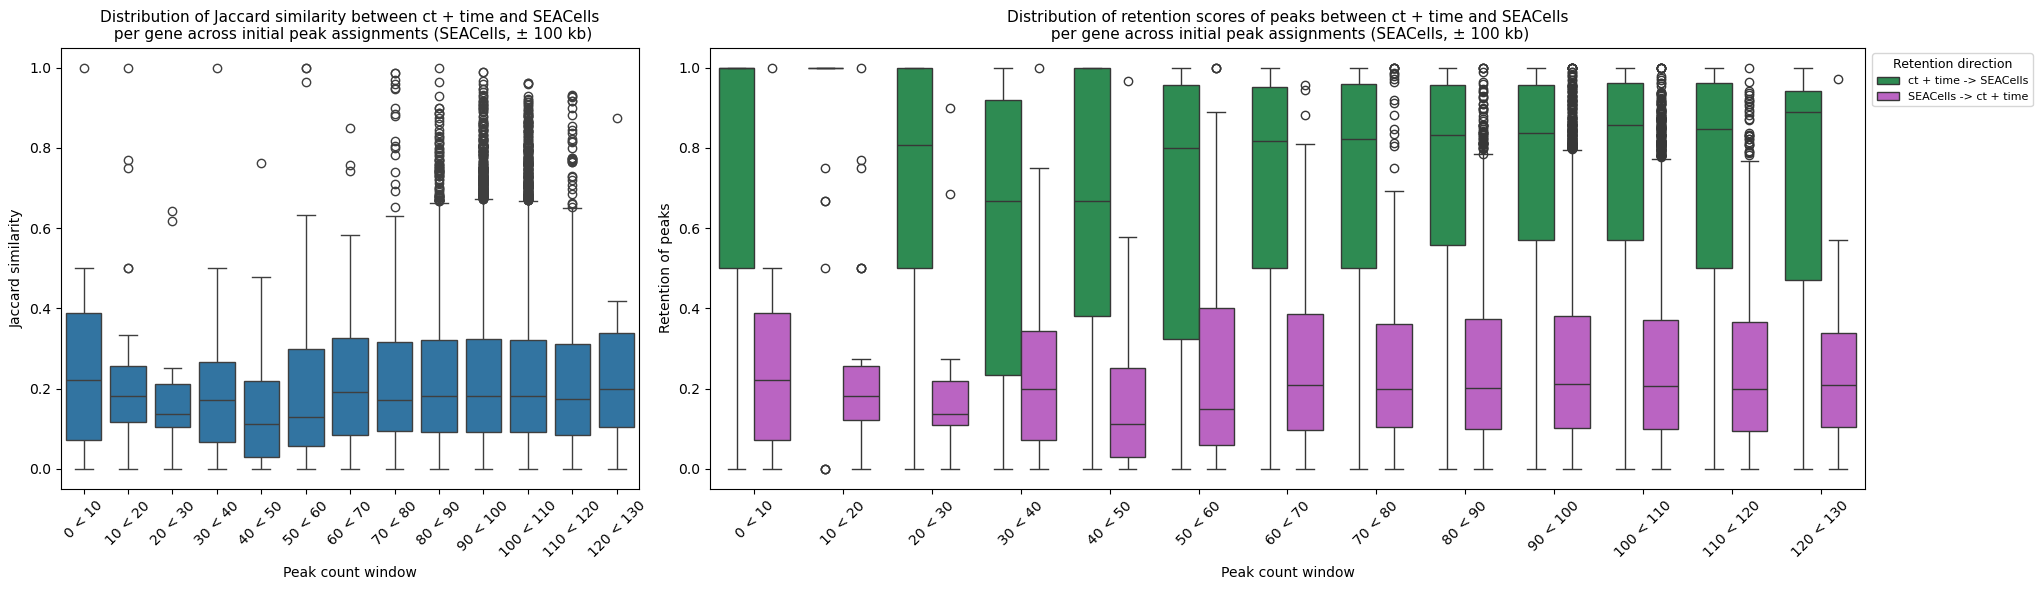

In [34]:
#plot boxplots of the jaccard similarity and retention values for each pair of window sizes, using the long format dataframes
import matplotlib.pyplot as plt
import seaborn as sns   


fig, axes = plt.subplots(1,2, figsize=(22, 6), gridspec_kw={'width_ratios': [1, 2]})

sns.boxplot(x="w1", y="jaccard", data=jaccard_long, ax=axes[0])
#make the plot quadratic
axes[0].tick_params(axis='x', rotation=45)
#negative log scale the y-axis of the jaccard similarity plot to better visualize the distribution of values, since many values are close to 0
#axes[0].set_yscale('log')
axes[0].set_xlabel("Peak count window")
axes[0].set_ylabel("Jaccard similarity")
axes[0].set_title("Distribution of Jaccard similarity between ct + time and SEACells\n per gene across initial peak assignments (SEACells, ± 100 kb)", fontsize=11)

method_colors = {"ct + time -> SEACells": "#1e9b4e", "SEACells -> ct + time": "#c755d1"}

sns.boxplot(x="w1", y="retention", hue="comparison", data=retention_long_combined, palette=method_colors)
plt.xticks(rotation=45)
plt.xlabel("Peak count window")
plt.ylabel("Retention of peaks")
plt.title("Distribution of retention scores of peaks between ct + time and SEACells\n per gene across initial peak assignments (SEACells, ± 100 kb)", fontsize=11)
plt.legend(title="Retention direction", loc="upper right", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.15, 1), frameon=True)
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # make room for the legend
plt.show()



In [276]:
#load the dataframes back in to check if they are saved correctly
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/jaccard_long_100kb_cor.csv")
retention_long_ctt_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_ctt_sc_100kb_cor.csv")
retention_long_sc_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_sc_ctt_100kb_cor.csv")

#print the first few rows of each dataframe to check if they are loaded correctly
print(jaccard_long.head())
print(retention_long_ctt_sc.head())
print(retention_long_sc_ctt.head())

       w1      w2               gene  jaccard
0  0 < 10  0 < 10   si:dkeyp-80d11.4      0.0
1  0 < 10  0 < 10   si:ch211-237a4.2      1.0
2  0 < 10  0 < 10             znf973      0.2
3  0 < 10  0 < 10  si:ch211-207e19.2      0.5
4  0 < 10  0 < 10            znf1072      0.4
       w1      w2               gene  retention
0  0 < 10  0 < 10   si:dkeyp-80d11.4        0.0
1  0 < 10  0 < 10   si:ch211-237a4.2        1.0
2  0 < 10  0 < 10             znf973        1.0
3  0 < 10  0 < 10  si:ch211-207e19.2        1.0
4  0 < 10  0 < 10            znf1072        1.0
       w1      w2               gene  retention
0  0 < 10  0 < 10   si:dkeyp-80d11.4        0.0
1  0 < 10  0 < 10   si:ch211-237a4.2        1.0
2  0 < 10  0 < 10             znf973        0.2
3  0 < 10  0 < 10  si:ch211-207e19.2        0.5
4  0 < 10  0 < 10            znf1072        0.4


In [277]:
#aggregate all matrixs into a long dataframe with columns w1, w2, score_type, score_value
window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

#aggregate all long dataframes into a single long dataframe with columns w1, w2, score_type, score_value
jaccard_long["score_value"] = jaccard_long["jaccard"]
retention_long_ctt_sc["score_value"] = retention_long_ctt_sc["retention"]
retention_long_sc_ctt["score_value"] = retention_long_sc_ctt["retention"]

jaccard_long["score_type"] = "jaccard"
retention_long_ctt_sc["score_type"] = "retention_ctt_sc"
retention_long_sc_ctt["score_type"] = "retention_sc_ctt"

all_scores_long_df = pd.concat([jaccard_long, retention_long_ctt_sc, retention_long_sc_ctt], ignore_index=True)
all_scores_long_df = all_scores_long_df[["w1", "w2", "score_type", "score_value"]]
all_scores_long_df = all_scores_long_df.dropna(subset=["score_value"])  # drop rows where score_value is NaN
print(all_scores_long_df.head())

print(all_scores_long_df.dtypes)
print(all_scores_long_df["score_value"].dtype)  # check the dtype of score_value column

       w1      w2 score_type  score_value
0  0 < 10  0 < 10    jaccard          0.0
1  0 < 10  0 < 10    jaccard          1.0
2  0 < 10  0 < 10    jaccard          0.2
3  0 < 10  0 < 10    jaccard          0.5
4  0 < 10  0 < 10    jaccard          0.4
w1              object
w2              object
score_type      object
score_value    float64
dtype: object
float64


/tmp/ipykernel_1407594/77013549.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_labels_with_counts, rotation=45, ha="center")


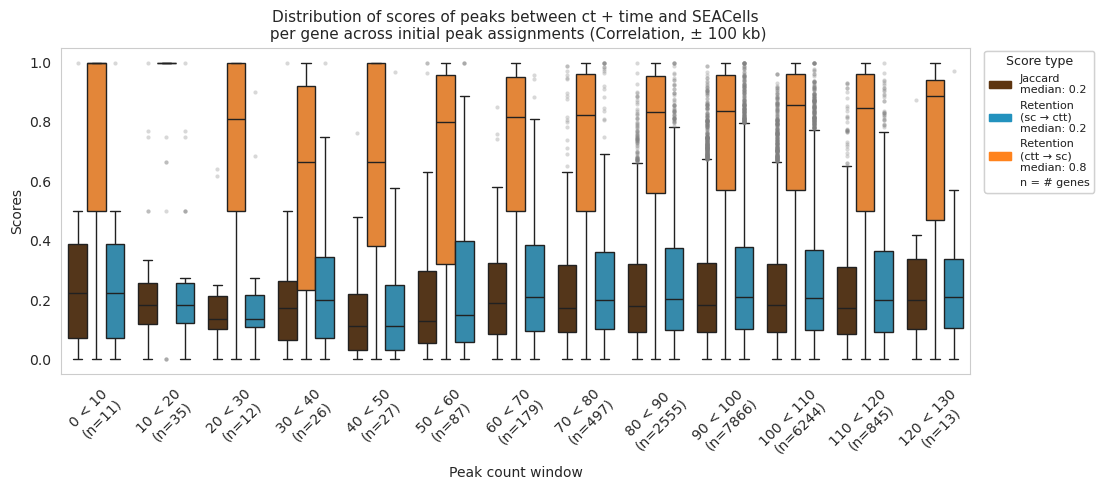

In [278]:
#barplot of the scores from all_scores_long_df, with x-axis = w1, y-axis = score_value, hue = score_type in one plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- counts per diagonal window ---
jaccard_counts = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)
method_colors = {
    "jaccard": "#5e3510",
    "retention_ctt_sc": "#ff831d",
    "retention_sc_ctt": "#2392be"
}

fig, axes = plt.subplots(figsize=(13, 5))

flier_props = dict(
    marker="o",
    markerfacecolor="gray",
    markeredgecolor="none",
    markersize=3,
    alpha=0.3,
)

sns.boxplot(x="w1", y="score_value", hue="score_type", data=all_scores_long_df, palette=method_colors, ax= axes, flierprops=flier_props)
sns.set_style("whitegrid")
median_scores = all_scores_long_df.groupby(["w1", "score_type"])["score_value"].median().reset_index()
axes.get_legend().remove()  # Remove seaborn's legend first

# --- score type legend ---
score_handles = [
    mpatches.Patch(color=method_colors["jaccard"],      label=f"Jaccard \nmedian: {median_scores[median_scores['score_type'] == 'jaccard']['score_value'].median():.1f} "),
    mpatches.Patch(color=method_colors["retention_sc_ctt"], label=f"Retention \n(sc → ctt) \nmedian: {median_scores[median_scores['score_type'] == 'retention_sc_ctt']['score_value'].median():.1f}"),
    mpatches.Patch(color=method_colors["retention_ctt_sc"], label=f"Retention \n(ctt → sc) \nmedian: {median_scores[median_scores['score_type'] == 'retention_ctt_sc']['score_value'].median():.1f}"),
    mpatches.Patch(color="none", label= f"n = # genes")  # empty patch for spacing
]
score_legend = fig.legend(
    handles=score_handles,
    title="Score type",
    loc="upper right",
    bbox_to_anchor=(0.85, 0.9),
    fontsize=8, title_fontsize=9,
    frameon=True,
)
score_legend.get_title().set_ha("center")
axes.add_artist(score_legend)

#add the jaccard_counts to the x-axis labels
x_labels_with_counts = [f"{w} \n(n={int(jaccard_counts.loc[w, w])})" for w in window_labels]
axes.set_xticklabels(x_labels_with_counts, rotation=45, ha="center")  

plt.xticks(rotation=45)
plt.xlabel("Peak count window")
plt.ylabel("Scores")
plt.title("Distribution of scores of peaks between ct + time and SEACells\n per gene across initial peak assignments (Correlation, ± 100 kb)", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(right=0.75)  # make room on the right for both legends
plt.show()

# Create list of genes with significant peaks selected by Correlation on different resolution

In [228]:
#load the correlation results for ct + time and SEACells 
import pandas as pd
cor_res_100kb_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")
print(cor_res_100kb_ctt.head())

cor_res_100kb_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
cor_res_100kb_sc.head()

  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj  
0  0.034600       1.460927  
1  0.173677       0.760259  
2  0.472269       0.325810  
3  0.217494       0.662553  
4  0.748452       0.125836  


,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj
0,100kb,a1cf,12-6186644-6187111,0.121149,0.000016,4.791006,0.000055,4.261565
1,100kb,a1cf,12-6190483-6191143,0.117048,0.000031,4.506702,0.000099,4.004141
2,100kb,a1cf,12-6225169-6226018,0.061143,0.029989,1.523041,0.048167,1.317250
3,100kb,a1cf,12-6114452-6114950,0.060388,0.032080,1.493760,0.051156,1.291101
4,100kb,a1cf,12-6140521-6140735,0.012429,0.659394,0.180855,0.714356,0.146085


In [229]:
# classify every peak–gene pair into one of three categories to cor results

def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb_sc["category"] = cor_res_100kb_sc.apply(classify_pair, axis=1)
cor_res_100kb_ctt["category"] = cor_res_100kb_ctt.apply(classify_pair, axis=1)

In [42]:
#creat a dictionary with the significant peaks for each gene 

significant_peaks_dict_ctt = {}
for gene_id, group in cor_res_100kb_ctt.groupby("gene"):
    sig_peaks = group[group["category"].isin(["sig. negative", "sig. positive"])]["peak"].tolist()
    significant_peaks_dict_ctt[gene_id] = sig_peaks

significant_peaks_dict_sc = {}
for gene_id, group in cor_res_100kb_sc.groupby("gene"):
    sig_peaks = group[group["category"].isin(["sig. negative", "sig. positive"])]["peak"].tolist()
    significant_peaks_dict_sc[gene_id] = sig_peaks

print(next(iter(significant_peaks_dict_ctt.items())))
print(next(iter(significant_peaks_dict_sc.items())))

('a1cf', ['12-6186644-6187111', '12-6110375-6111134', '12-6163466-6163906', '12-6201711-6202346', '12-6255500-6255954', '12-6194740-6195637', '12-6098047-6099324', '12-6205005-6206034', '12-6242806-6243344', '12-6182609-6183304', '12-6207799-6208138', '12-6176521-6177141', '12-6186318-6186534', '12-6135283-6136959', '12-6177594-6178380', '12-6174866-6175973', '12-6262721-6263344', '12-6273948-6274547', '12-6169328-6170580', '12-6171543-6171943', '12-6191943-6192142', '12-6168075-6169044', '12-6254277-6254476', '12-6213330-6214602', '12-6115965-6116256', '12-6133237-6133668', '12-6102272-6102961', '12-6099899-6100254'])
('a1cf', ['12-6186644-6187111', '12-6190483-6191143', '12-6225169-6226018', '12-6100792-6101473', '12-6163466-6163906', '12-6226949-6227335', '12-6266602-6267534', '12-6260921-6261335', '12-6201711-6202346', '12-6255500-6255954', '12-6211542-6212324', '12-6194740-6195637', '12-6188050-6188583', '12-6130915-6131954', '12-6106568-6107956', '12-6268971-6269807', '12-6205005

In [43]:
#count the number of significant peaks for each gene in both dictionaries and store the counts in a new dataframe with columns gene, n_sig_peaks_ctt, n_sig_peaks_sc
import pandas as pd
gene_counts = []
for gene in set(list(significant_peaks_dict_ctt.keys()) + list(significant_peaks_dict_sc.keys())):
    n_sig_peaks_ctt = len(significant_peaks_dict_ctt.get(gene, []))
    n_sig_peaks_sc = len(significant_peaks_dict_sc.get(gene, []))
    gene_counts.append({
        "gene": gene,
        "n_sig_peaks_ctt": n_sig_peaks_ctt,
        "n_sig_peaks_sc": n_sig_peaks_sc
    })
gene_counts_df = pd.DataFrame(gene_counts)

print(gene_counts_df.head())

      gene  n_sig_peaks_ctt  n_sig_peaks_sc
0     pld6               12              33
1    rad9b                7              21
2   slc3a1               30              76
3  znf1002               25              73
4     alad               52              43


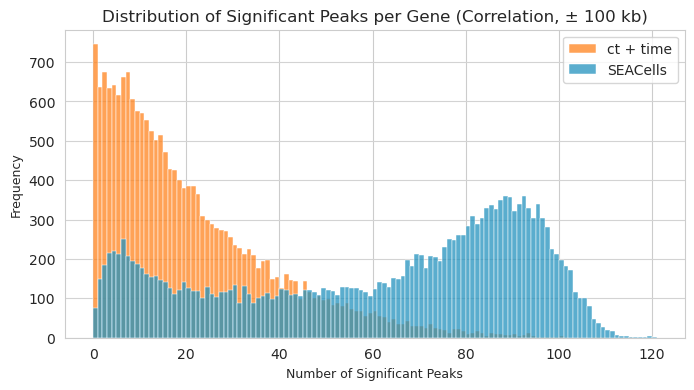

In [274]:
#plot of the distribution of the number of significant peaks per gene in gene_counts df
import matplotlib.pyplot as plt
import seaborn as sns
colors = ["#ff831d", "#2392be"]  # colors for ct + time and SEACells
plt.figure(figsize=(8, 4))
sns.histplot(data=gene_counts_df, x="n_sig_peaks_ctt", label="ct + time",bins=range(0, gene_counts_df["n_sig_peaks_ctt"].max() + 1), color=colors[0])
sns.histplot(data=gene_counts_df, x="n_sig_peaks_sc", label="SEACells", bins=range(0, gene_counts_df["n_sig_peaks_sc"].max() + 1), color=colors[1])
#whitegrid background 
sns.set_style("whitegrid", {'axes.grid': False, 'grid.color': 'lightgray', 'grid.linestyle': '-'})
plt.grid(True, axis='y', color='lightgray', linestyle='-')
plt.xlabel("Number of Significant Peaks", fontsize=9)
plt.ylabel("Frequency", fontsize=9)
plt.title("Distribution of Significant Peaks per Gene (Correlation, ± 100 kb)")
plt.legend()
plt.show()

In [84]:
#create a dataframe that includes genes, n_sig_peaks_ctt, n_sig_peaks_sc, and sig_peak_window based on resolution (ctt or sc)
import numpy as np
max_peaks = gene_counts_df[["n_sig_peaks_ctt", "n_sig_peaks_sc"]].max().max()
bin_edges = np.arange(0, max_peaks + 10, 10)  # 0, 10, 20, ..., covering max_peaks

labels = ["0"] + [f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges)-1)]

gene_counts_df["sig_peak_window_ctt"] = pd.cut(gene_counts_df["n_sig_peaks_ctt"], bins=[-1] + list(bin_edges), labels=labels, right=True)
gene_counts_df["sig_peak_window_sc"] = pd.cut(gene_counts_df["n_sig_peaks_sc"], bins=[-1] + list(bin_edges), labels=labels, right=True)


In [13]:
gene_counts_df.head()

,gene,n_sig_peaks_ctt,n_sig_peaks_sc,sig_peak_window_ctt,sig_peak_window_sc
0,yy1a,7,69,0-10,60-70
1,kdm5bb,19,32,10-20,30-40
2,plxna1a,68,100,60-70,90-100
3,selenbp1,37,101,30-40,100-110
4,nifk,34,9,30-40,0-10


In [85]:
#save the gene_counts_df to a csv file
gene_counts_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/resolution_window.csv", index=False)

# Add resolution based annotations

In [247]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/jaccard_long_100kb_cor.csv")
retention_long_ctt_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_ctt_sc_100kb_cor.csv")
retention_long_sc_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_sc_ctt_100kb_cor.csv")

resolution_window_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/resolution_window.csv")

In [231]:
#see the unique values of the sig_peak_window_ctt and sig_peak_window_sc columns in the resolution_window_df dataframe
print(resolution_window_df["sig_peak_window_ctt"].sort_values().unique())
print(resolution_window_df["sig_peak_window_sc"].sort_values().unique())

['0' '0-10' '10-20' '100-110' '110-120' '20-30' '30-40' '40-50' '50-60'
 '60-70' '70-80' '80-90' '90-100']
['0' '0-10' '10-20' '100-110' '110-120' '120-130' '20-30' '30-40' '40-50'
 '50-60' '60-70' '70-80' '80-90' '90-100']


In [232]:
resolution_window_df[resolution_window_df["sig_peak_window_ctt"] == "0"].head()

,gene,n_sig_peaks_ctt,n_sig_peaks_sc,sig_peak_window_ctt,sig_peak_window_sc
79,ahsg1,0,3,0,0-10
120,il21,0,2,0,0-10
136,pth4,0,4,0,0-10
139,si:dkey-78l4.6,0,3,0,0-10
149,gstk4,0,2,0,0-10


In [ ]:
#rename the window labels in the long format dataframes to be more descriptive
window_label_mapping_ctt = {
    "0": "0",
    '0-10': '0 < 10',
    '10-20': '10 < 20',
    '20-30': '20 < 30',
    '30-40': '30 < 40',
    '40-50': '40 < 50',
    '50-60': '50 < 60',
    '60-70': '60 < 70',
    '70-80': '70 < 80',
    '80-90': '80 < 90',
    '90-100': '90 < 100',
    '100-110': '100 < 110',
    '110-120': '110 < 120',
}

#replace the columns with the new labels in the resolution_window_df dataframe
resolution_window_df["sig_peak_window_ctt"] = resolution_window_df["sig_peak_window_ctt"].replace(window_label_mapping_ctt)
resolution_window_df.head()

,gene,n_sig_peaks_ctt,n_sig_peaks_sc,sig_peak_window_ctt,sig_peak_window_sc
0,pld6,12,33,10 < 20,30 < 40
1,rad9b,7,21,0 < 10,20 < 30
2,slc3a1,30,76,20 < 30,70 < 80
3,znf1002,25,73,20 < 30,70 < 80
4,alad,52,43,50 < 60,40 < 50


In [285]:
resolution_window_df["sig_peak_window_ctt"].sort_values().unique()

array(['0', '0-10', '10-20', '100-110', '110-120', '20-30', '30-40',
       '40-50', '50-60', '60-70', '70-80', '80-90', '90-100'],
      dtype=object)

In [249]:
#add the sig_peak_window_ctt columns to the jaccard_long, retention_long_ctt_sc, and retention_long_sc_ctt dataframes by merging on gene column
jaccard_long = pd.merge(
    jaccard_long,
    resolution_window_df[["gene", "sig_peak_window_ctt"]],
    on="gene",
    how="left"
)

retention_long_ctt_sc = pd.merge(
    retention_long_ctt_sc,
    resolution_window_df[["gene", "sig_peak_window_ctt"]],
    on="gene",
    how="left"
)

retention_long_sc_ctt = pd.merge(
    retention_long_sc_ctt,
    resolution_window_df[["gene", "sig_peak_window_ctt"]],
    on="gene",
    how="left"
)


#aggregate all matrixs into a long dataframe with columns w1, w2, score_type, score_value
window_labels = ['0','0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120']

#aggregate all long dataframes into a single long dataframe with columns sig_peak_window_ctt, sig_peak_window_sc, score_type, score_value
jaccard_long["score_value"] = jaccard_long["jaccard"]
retention_long_ctt_sc["score_value"] = retention_long_ctt_sc["retention"]
retention_long_sc_ctt["score_value"] = retention_long_sc_ctt["retention"]

jaccard_long["score_type"] = "jaccard"
retention_long_ctt_sc["score_type"] = "retention_ctt_sc"
retention_long_sc_ctt["score_type"] = "retention_sc_ctt"

all_scores_long_df_ctt = pd.concat([jaccard_long, retention_long_ctt_sc, retention_long_sc_ctt], ignore_index=True)
all_scores_long_df_ctt = all_scores_long_df_ctt[["sig_peak_window_ctt", "score_type", "score_value"]]
all_scores_long_df_ctt = all_scores_long_df_ctt.dropna(subset=["score_value"])  # drop rows where score_value is NaN
print(all_scores_long_df_ctt.head())

print(all_scores_long_df_ctt.dtypes)
print(all_scores_long_df_ctt["score_value"].dtype)  # check the dtype of score_value column

  sig_peak_window_ctt score_type  score_value
0              0 < 10    jaccard          0.0
1              0 < 10    jaccard          1.0
2              0 < 10    jaccard          0.2
3              0 < 10    jaccard          0.5
4              0 < 10    jaccard          0.4
sig_peak_window_ctt     object
score_type              object
score_value            float64
dtype: object
float64


In [286]:
all_scores_long_df_ctt["sig_peak_window_ctt"].sort_values().unique()

array(['0 < 10', '10 < 20', '100 < 110', '110 < 120', '20 < 30',
       '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90',
       '90 < 100'], dtype=object)

In [250]:
#count the number of genes in each sig_peak_window_ctt and sig_peak_window_sc for each score_type in the long format dataframes
jaccard_count_ctt = jaccard_long.groupby("sig_peak_window_ctt")["gene"].nunique().reset_index(name="n_genes")
print(jaccard_count_ctt.head())


  sig_peak_window_ctt  n_genes
0              0 < 10     6267
1             10 < 20     4584
2           100 < 110        7
3           110 < 120        1
4             20 < 30     2967


In [251]:
jaccard_count_ctt["sig_peak_window_ctt"].unique()

array(['0 < 10', '10 < 20', '100 < 110', '110 < 120', '20 < 30',
       '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90',
       '90 < 100'], dtype=object)

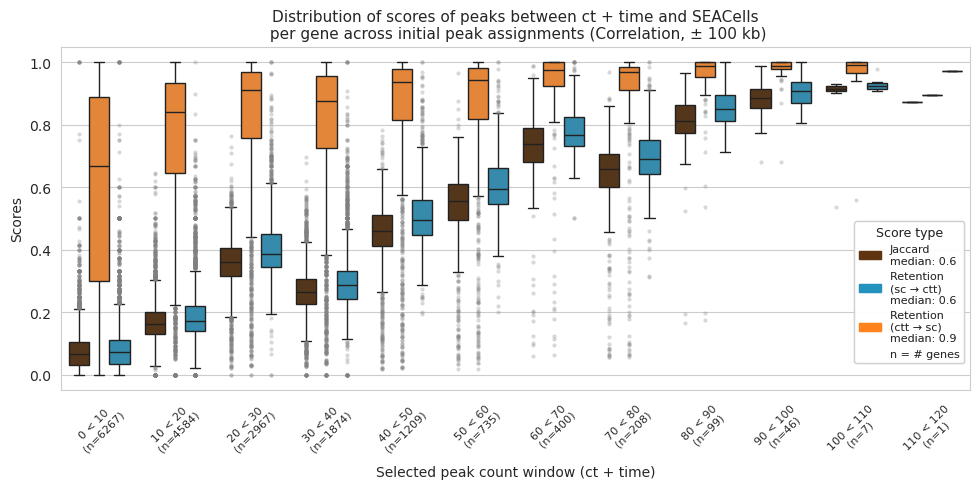

In [288]:
#barplot of the scores from all_scores_long_df, with x-axis = w1, y-axis = score_value, hue = score_type in one plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120']

method_colors = {
    "jaccard": "#5e3510",
    "retention_ctt_sc": "#ff831d",
    "retention_sc_ctt": "#2392be"
}

fig, axes = plt.subplots(figsize=(13, 5))

flier_props = dict(
    marker="o",
    markerfacecolor="gray",
    markeredgecolor="none",
    markersize=3,
    alpha=0.3,
)

sns.boxplot(x="sig_peak_window_ctt", y="score_value", hue="score_type", data=all_scores_long_df_ctt, palette=method_colors, ax= axes, flierprops=flier_props)
sns.set_style("whitegrid")
median_scores = all_scores_long_df_ctt.groupby(["sig_peak_window_ctt", "score_type"])["score_value"].median().reset_index()
axes.get_legend().remove()  # Remove seaborn's legend first

# --- score type legend ---
score_handles = [
    mpatches.Patch(color=method_colors["jaccard"],      label=f"Jaccard \nmedian: {median_scores[median_scores['score_type'] == 'jaccard']['score_value'].median():.1f} "),
    mpatches.Patch(color=method_colors["retention_sc_ctt"], label=f"Retention \n(sc → ctt) \nmedian: {median_scores[median_scores['score_type'] == 'retention_sc_ctt']['score_value'].median():.1f}"),
    mpatches.Patch(color=method_colors["retention_ctt_sc"], label=f"Retention \n(ctt → sc) \nmedian: {median_scores[median_scores['score_type'] == 'retention_ctt_sc']['score_value'].median():.1f}"),
    mpatches.Patch(color="none", label= f"n = # genes")  # empty patch for spacing
]
score_legend = fig.legend(
    handles=score_handles,
    title="Score type",
    loc="lower right",
    bbox_to_anchor=(0.75, 0.25),
    fontsize=8, title_fontsize=9,
    frameon=True,
)
score_legend.get_title().set_ha("center")
axes.add_artist(score_legend)

#add the jaccard_counts to the x-axis labels
x_labels_with_counts = [f"{w} \n(n={int(jaccard_count_ctt[jaccard_count_ctt['sig_peak_window_ctt'] == w]['n_genes'].values[0])})" for w in window_labels]
axes.set_xticks(range(len(window_labels)))
axes.set_xticklabels(x_labels_with_counts, rotation=45, ha="center", fontsize=8)  # set the x-tick labels with counts and adjust font size
plt.xticks(rotation=45)
plt.xlabel("Selected peak count window (ct + time)")
plt.ylabel("Scores")
plt.title("Distribution of scores of peaks between ct + time and SEACells\n per gene across initial peak assignments (Correlation, ± 100 kb)", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(right=0.75)  # make room on the right for both legends
plt.show()

In [280]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/jaccard_long_100kb_cor.csv")
retention_long_ctt_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_ctt_sc_100kb_cor.csv")
retention_long_sc_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/retention_long_sc_ctt_100kb_cor.csv")

resolution_window_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/resolution_window.csv")

In [281]:
window_label_mapping_sc = {
    "0": "0",
    '0-10': '0 < 10',
    '10-20': '10 < 20',
    '20-30': '20 < 30',
    '30-40': '30 < 40',
    '40-50': '40 < 50',
    '50-60': '50 < 60',
    '60-70': '60 < 70',
    '70-80': '70 < 80',
    '80-90': '80 < 90',
    '90-100': '90 < 100',
    '100-110': '100 < 110',
    '110-120': '110 < 120',
    '120-130': '120 < 130',
}
resolution_window_df["sig_peak_window_sc"] = resolution_window_df["sig_peak_window_sc"].replace(window_label_mapping_sc)
resolution_window_df.head()

,gene,n_sig_peaks_ctt,n_sig_peaks_sc,sig_peak_window_ctt,sig_peak_window_sc
0,pld6,12,33,10-20,30 < 40
1,rad9b,7,21,0-10,20 < 30
2,slc3a1,30,76,20-30,70 < 80
3,znf1002,25,73,20-30,70 < 80
4,alad,52,43,50-60,40 < 50


In [282]:
#add the sig_peak_window_ctt columns to the jaccard_long, retention_long_ctt_sc, and retention_long_sc_ctt dataframes by merging on gene column
jaccard_long = pd.merge(
    jaccard_long,
    resolution_window_df[["gene", "sig_peak_window_sc"]],
    on="gene",
    how="left"
)

retention_long_ctt_sc = pd.merge(
    retention_long_ctt_sc,
    resolution_window_df[["gene", "sig_peak_window_sc"]],
    on="gene",
    how="left"
)

retention_long_sc_ctt = pd.merge(
    retention_long_sc_ctt,
    resolution_window_df[["gene", "sig_peak_window_sc"]],
    on="gene",
    how="left"
)


#aggregate all matrixs into a long dataframe with columns w1, w2, score_type, score_value
window_labels = ['0','0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120']

#aggregate all long dataframes into a single long dataframe with columns sig_peak_window_ctt, sig_peak_window_sc, score_type, score_value
jaccard_long["score_value"] = jaccard_long["jaccard"]
retention_long_ctt_sc["score_value"] = retention_long_ctt_sc["retention"]
retention_long_sc_ctt["score_value"] = retention_long_sc_ctt["retention"]

jaccard_long["score_type"] = "jaccard"
retention_long_ctt_sc["score_type"] = "retention_ctt_sc"
retention_long_sc_ctt["score_type"] = "retention_sc_ctt"

all_scores_long_df_sc = pd.concat([jaccard_long, retention_long_ctt_sc, retention_long_sc_ctt], ignore_index=True)
all_scores_long_df_sc = all_scores_long_df_sc[["sig_peak_window_sc", "score_type", "score_value"]]
all_scores_long_df_sc = all_scores_long_df_sc.dropna(subset=["score_value"])  # drop rows where score_value is NaN
print(all_scores_long_df_sc.head())

print(all_scores_long_df_sc.dtypes)
print(all_scores_long_df_sc["score_value"].dtype)  # check the dtype of score_value column

  sig_peak_window_sc score_type  score_value
0             0 < 10    jaccard          0.0
1             0 < 10    jaccard          1.0
2             0 < 10    jaccard          0.2
3             0 < 10    jaccard          0.5
4             0 < 10    jaccard          0.4
sig_peak_window_sc     object
score_type             object
score_value           float64
dtype: object
float64


In [283]:
#count the number of genes in each sig_peak_window_ctt and sig_peak_window_sc for each score_type in the long format dataframes
jaccard_count_sc = jaccard_long.groupby("sig_peak_window_sc")["gene"].nunique().reset_index(name="n_genes")
print(jaccard_count_sc.head())


  sig_peak_window_sc  n_genes
0             0 < 10     1489
1            10 < 20     1288
2          100 < 110      882
3          110 < 120       43
4          120 < 130        3


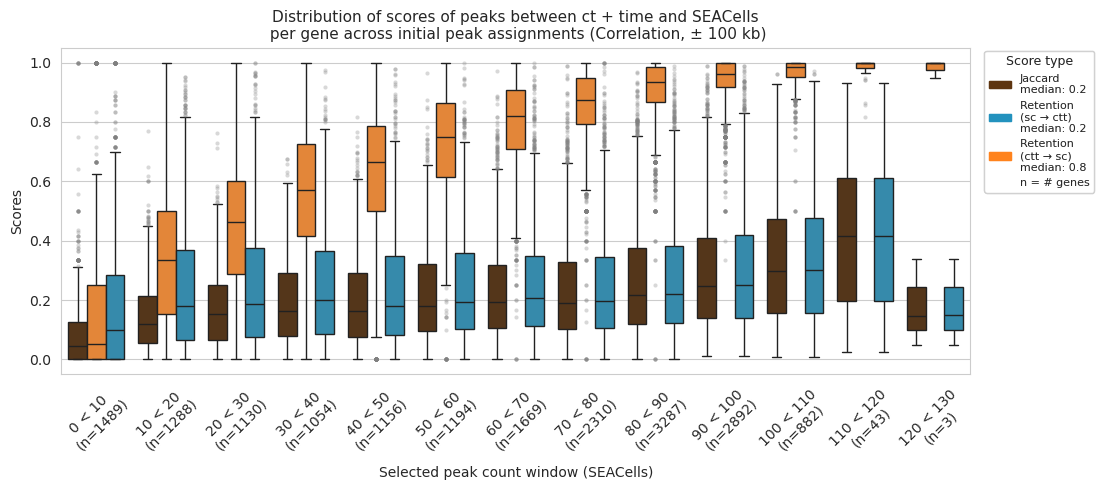

In [284]:
#barplot of the scores from all_scores_long_df, with x-axis = w1, y-axis = score_value, hue = score_type in one plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

method_colors = {
    "jaccard": "#5e3510",
    "retention_ctt_sc": "#ff831d",
    "retention_sc_ctt": "#2392be"
}

fig, axes = plt.subplots(figsize=(13, 5))

flier_props = dict(
    marker="o",
    markerfacecolor="gray",
    markeredgecolor="none",
    markersize=3,
    alpha=0.3,
)

sns.boxplot(x="sig_peak_window_sc", y="score_value", hue="score_type", data=all_scores_long_df_sc, palette=method_colors, ax= axes, flierprops=flier_props)
sns.set_style("whitegrid")
median_scores = all_scores_long_df_sc.groupby(["sig_peak_window_sc", "score_type"])["score_value"].median().reset_index()
axes.get_legend().remove()  # Remove seaborn's legend first

# --- score type legend ---
score_handles = [
    mpatches.Patch(color=method_colors["jaccard"],      label=f"Jaccard \nmedian: {median_scores[median_scores['score_type'] == 'jaccard']['score_value'].median():.1f} "),
    mpatches.Patch(color=method_colors["retention_sc_ctt"], label=f"Retention \n(sc → ctt) \nmedian: {median_scores[median_scores['score_type'] == 'retention_sc_ctt']['score_value'].median():.1f}"),
    mpatches.Patch(color=method_colors["retention_ctt_sc"], label=f"Retention \n(ctt → sc) \nmedian: {median_scores[median_scores['score_type'] == 'retention_ctt_sc']['score_value'].median():.1f}"),
    mpatches.Patch(color="none", label= f"n = # genes")  # empty patch for spacing
]
score_legend = fig.legend(
    handles=score_handles,
    title="Score type",
    loc="upper right",
    bbox_to_anchor=(0.85, 0.9),
    fontsize=8, title_fontsize=9,
    frameon=True,
)
score_legend.get_title().set_ha("center")
axes.add_artist(score_legend)

#add the jaccard_counts to the x-axis labels
x_labels_with_counts = [f"{w} \n(n={int(jaccard_count_sc[jaccard_count_sc['sig_peak_window_sc'] == w]['n_genes'].values[0])})" for w in window_labels]
axes.set_xticks(range(len(window_labels)))
axes.set_xticklabels(x_labels_with_counts, rotation=45, ha="center")
plt.xticks(rotation=45)
plt.xlabel("Selected peak count window (SEACells)")
plt.ylabel("Scores")
plt.title("Distribution of scores of peaks between ct + time and SEACells\n per gene across initial peak assignments (Correlation, ± 100 kb)", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(right=0.75)  # make room on the right for both legends
plt.show()

In [290]:
n_genes_ctt = jaccard_count_ctt["n_genes"].sum()
n_genes_sc = jaccard_count_sc["n_genes"].sum()
print(f"Total number of genes in ct + time: {n_genes_ctt}")
print(f"Total number of genes in SEACells: {n_genes_sc}")

Total number of genes in ct + time: 18397
Total number of genes in SEACells: 18397
